# Histogram plots and CLAHE with pyclesperanto

This notebook demonstrates how to compute and plot the intensity histogram of an image with
`cle.histogram()`, and how to enhance local contrast with `cle.clahe()` (Contrast Limited
Adaptive Histogram Equalization), comparing histograms before and after.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
import pyclesperanto as cle

cle.select_device()

(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

## Load the example image

array([[ 40,  32,  24, ..., 216, 200, 200],
       [ 56,  40,  24, ..., 232, 216, 216],
       [ 64,  48,  24, ..., 240, 232, 232],
       ...,
       [ 72,  80,  80, ...,  48,  48,  48],
       [ 80,  80,  80, ...,  48,  48,  48],
       [ 96,  88,  80, ...,  48,  48,  48]], shape=(254, 256), dtype=uint8, mtype=buffer)
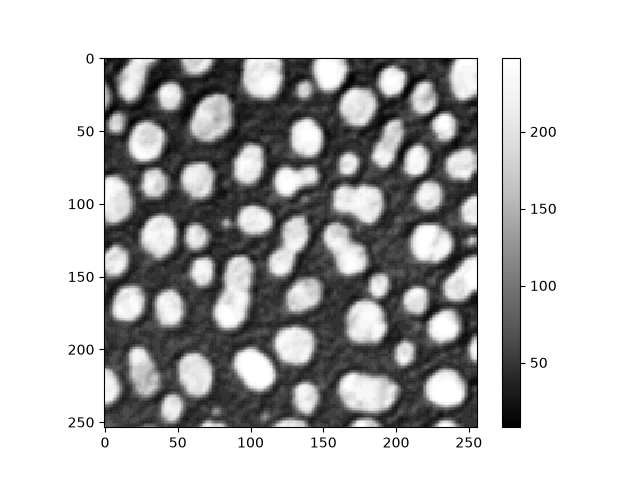
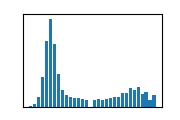

In [2]:
image = cle.push(imread('https://samples.fiji.sc/blobs.png').squeeze())
image

## 1. Compute and plot histogram

`cle.histogram()` returns a 1D array of bin counts, uniformly distributed between the min and
max intensity of the image (or an explicit range).

In [8]:
hist = cle.histogram(image, num_bins=256)
hist.shape

(256,)

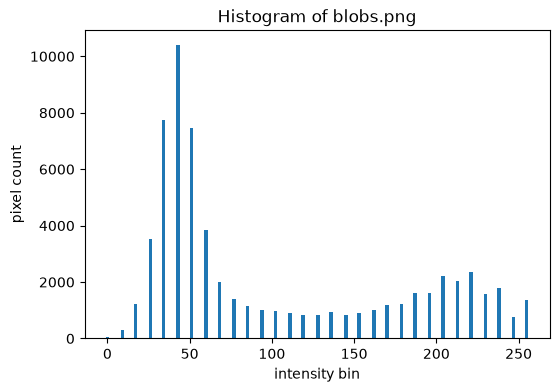

In [20]:
plt.figure(figsize=(6, 4))
plt.bar(np.arange(len(hist)), hist.get(), width=2)
plt.xlabel("intensity bin")
plt.ylabel("pixel count")
plt.title("Histogram of blobs.png")
plt.show()

## 3. CLAHE (Contrast Limited Adaptive Histogram Equalization)

`cle.clahe()` locally equalizes the histogram in tiles of size `tile_size`, clipped by
`clip_limit`, to enhance local contrast without over-amplifying noise.

array([[ 19,   8,   0, ..., 204, 182, 179],
       [ 41,  19,   0, ..., 224, 203, 201],
       [ 53,  31,   0, ..., 236, 224, 223],
       ...,
       [ 47,  59,  59, ...,  12,   4,   0],
       [ 53,  53,  53, ...,   4,   0,   0],
       [ 70,  57,  45, ...,   0,   0,   0]], shape=(254, 256), dtype=uint8, mtype=buffer)
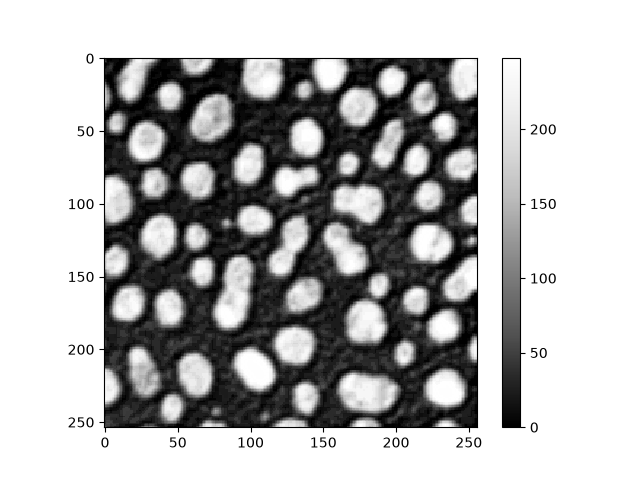
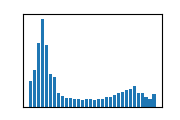

In [21]:
equalized = cle.clahe(image, tile_size=8, clip_limit=0.01)
eqhist = cle.histogram(equalized, num_bins=256)
equalized

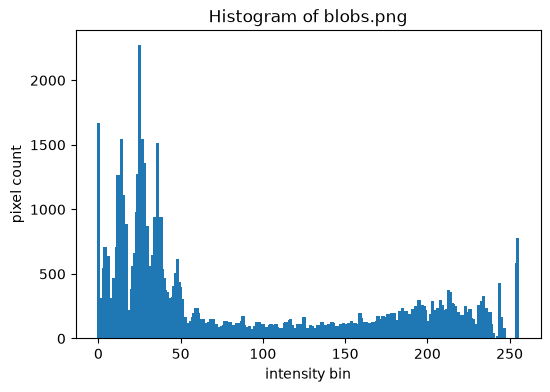

In [22]:
plt.figure(figsize=(6, 4))
plt.bar(np.arange(len(eqhist)), eqhist.get(), width=2)
plt.xlabel("intensity bin")
plt.ylabel("pixel count")
plt.title("Histogram of blobs.png")
plt.show()

> CLAHE redistributes intensities more evenly across the histogram, improving local contrast, while `clip_limit` prevents over-amplification of noise in near-uniform tiles.

## 4. CLAHE intensity correction real case

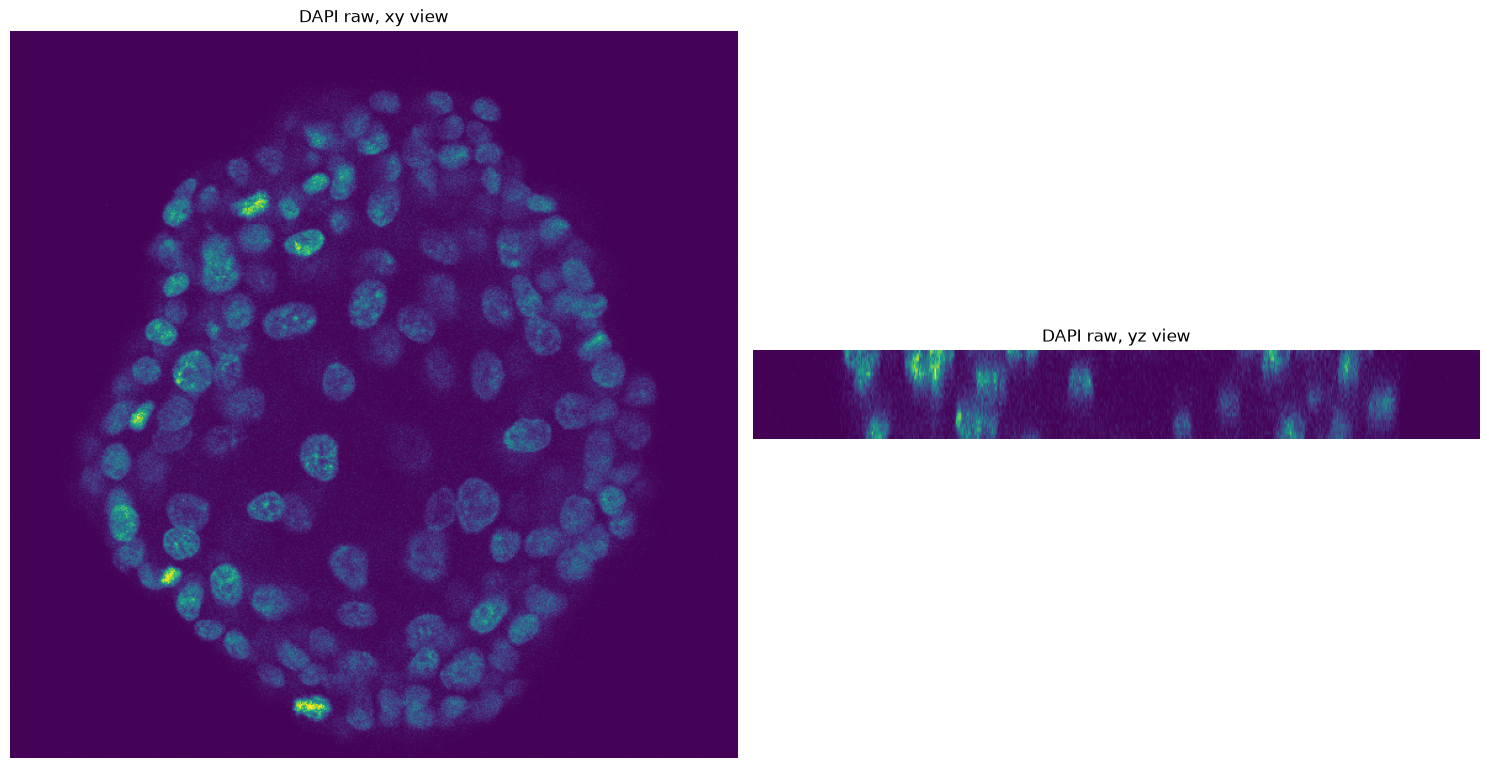

In [ ]:
image = "https://github.com/StRigaud/pyopencl_clahe/raw/refs/heads/main/Test_image/TOrg2%20DAPI-1.tif"
raw = imread(image)
halfz = int(np.shape(raw)[0]/2)
halfx = int(np.shape(raw)[2]/2)

fig, axs = plt.subplots(1,2,figsize=(15,10))
axs[0].imshow(raw[halfz], cmap="viridis")
axs[1].imshow(raw[:,halfx,:], aspect = 3, cmap="viridis")
axs[0].set_title('DAPI raw, xy view')
axs[1].set_title('DAPI raw, yz view')
for ax in axs.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

In [25]:
results_gpu = cle.clahe(raw, tile_size=8, clip_limit=0.01)

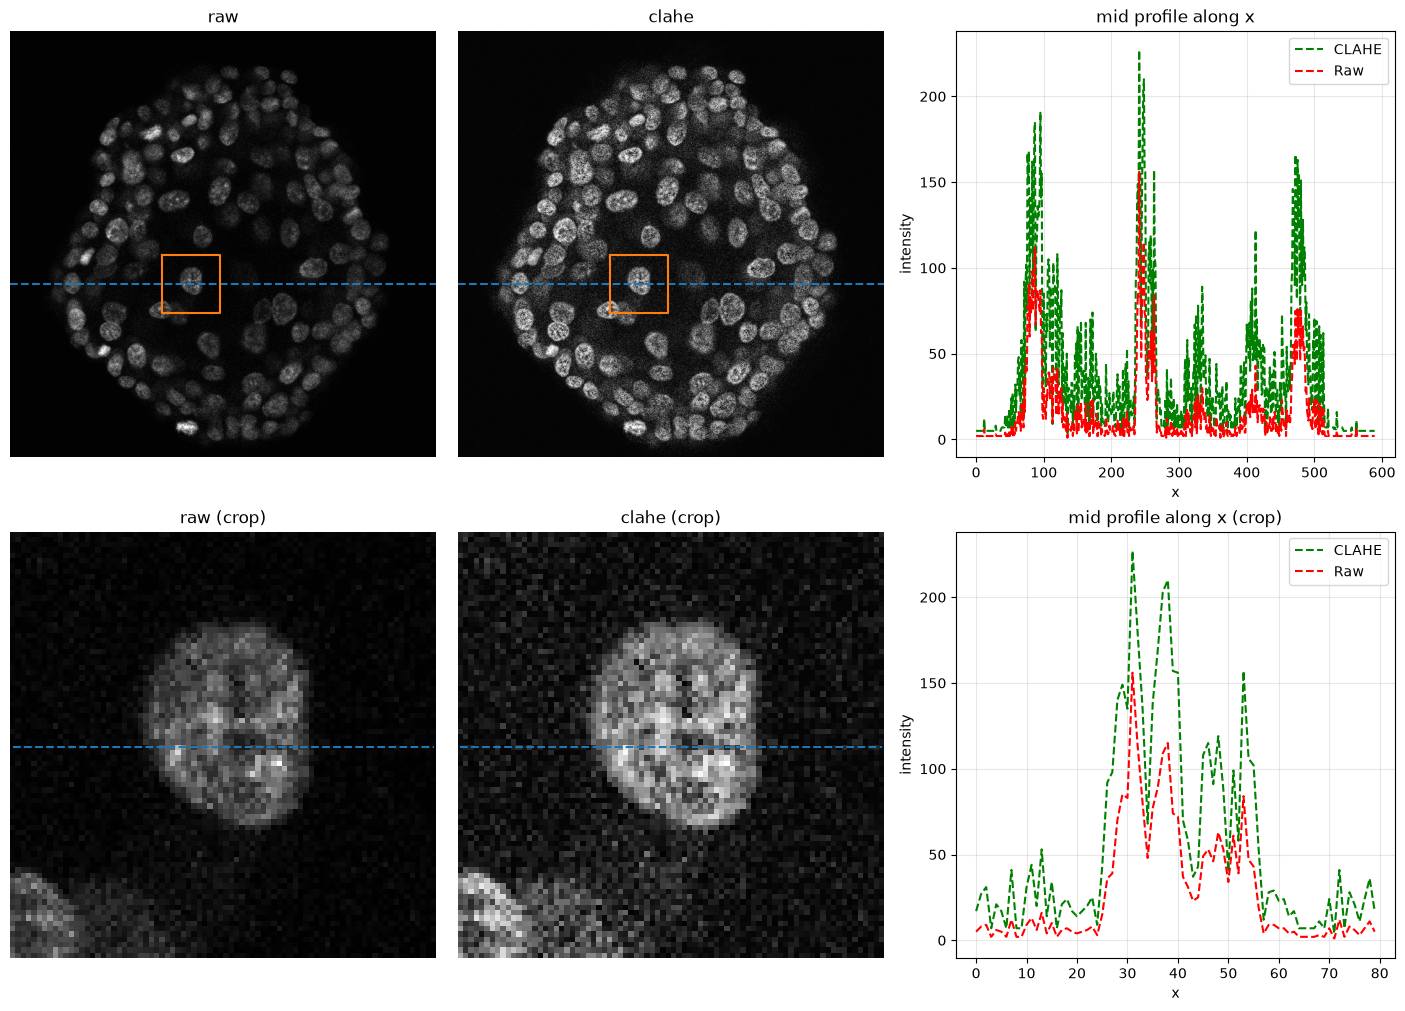

In [26]:
result = results_gpu.get()

radius = 40
corner = [350, 250]
crop_raw = raw[np.shape(raw)[0]//2, corner[0]-radius:corner[0]+radius, corner[1]-radius:corner[1]+radius]
crop_res = result[np.shape(raw)[0]//2, corner[0]-radius:corner[0]+radius, corner[1]-radius:corner[1]+radius]

profile_raw = raw[np.shape(raw)[0]//2, 350, :]
profile_pro = result[np.shape(raw)[0]//2, 350, :]
profile_raw_crop = crop_raw[crop_raw.shape[0]//2, :]
profile_pro_crop = crop_res[crop_res.shape[0]//2, :]

fig, axs = plt.subplots(2, 3, figsize=(14, 10), constrained_layout=True)

axs[0, 0].imshow(raw[np.shape(raw)[0]//2], cmap="gray")
axs[0, 0].set_title("raw")
axs[0, 0].set_axis_off()
axs[0, 0].plot([0, raw.shape[2]-1],[350, 350], "--")
axs[0, 0].plot([corner[1]-radius, corner[1]+radius, corner[1]+radius, corner[1]-radius, corner[1]-radius],
               [corner[0]-radius, corner[0]-radius, corner[0]+radius, corner[0]+radius, corner[0]-radius])
    
axs[0, 1].imshow(result[halfz], cmap="gray")
axs[0, 1].set_title("clahe")
axs[0, 1].set_axis_off()
axs[0, 1].plot([0, result.shape[2]-1],[350, 350], "--")
axs[0, 1].plot([corner[1]-radius, corner[1]+radius, corner[1]+radius, corner[1]-radius, corner[1]-radius],
               [corner[0]-radius, corner[0]-radius, corner[0]+radius, corner[0]+radius, corner[0]-radius])

x_full = np.arange(profile_pro.size)
axs[0, 2].plot(x_full, profile_pro, "--", color="g", label="CLAHE")
axs[0, 2].plot(x_full, profile_raw, "--", color="r", label="Raw")
axs[0, 2].set_title("mid profile along x")
axs[0, 2].set_xlabel("x")
axs[0, 2].set_ylabel("intensity")
axs[0, 2].grid(alpha=0.3)
axs[0, 2].legend(frameon=True)

axs[1, 0].imshow(crop_raw, cmap="gray")
axs[1, 0].set_title("raw (crop)")
axs[1, 0].set_axis_off()
axs[1, 0].plot([0, crop_raw.shape[1]-1],[crop_raw.shape[0]//2, crop_raw.shape[0]//2], "--")

axs[1, 1].imshow(crop_res, cmap="gray")
axs[1, 1].set_title("clahe (crop)")
axs[1, 1].set_axis_off()
axs[1, 1].plot([0, crop_res.shape[1]-1],[crop_res.shape[0]//2, crop_res.shape[0]//2], "--")

x_crop = np.arange(profile_pro_crop.size)
axs[1, 2].plot(x_crop, profile_pro_crop, "--", color="g", label="CLAHE")
axs[1, 2].plot(x_crop, profile_raw_crop, "--", color="r", label="Raw")
axs[1, 2].set_title("mid profile along x (crop)")
axs[1, 2].set_xlabel("x")
axs[1, 2].set_ylabel("intensity")
axs[1, 2].grid(alpha=0.3)
axs[1, 2].legend(frameon=True)

ymin = np.nanmin([
    np.nanmin(profile_pro), np.nanmin(profile_raw),
    np.nanmin(profile_pro_crop), np.nanmin(profile_raw_crop)
])
ymax = np.nanmax([
    np.nanmax(profile_pro), np.nanmax(profile_raw),
    np.nanmax(profile_pro_crop), np.nanmax(profile_raw_crop)
])
pad = 0.05 * (ymax - ymin) if ymax > ymin else 1.0
for ax in (axs[0, 2], axs[1, 2]):
    ax.set_ylim(ymin - pad, ymax + pad)

plt.show()

as well as in 3D ...

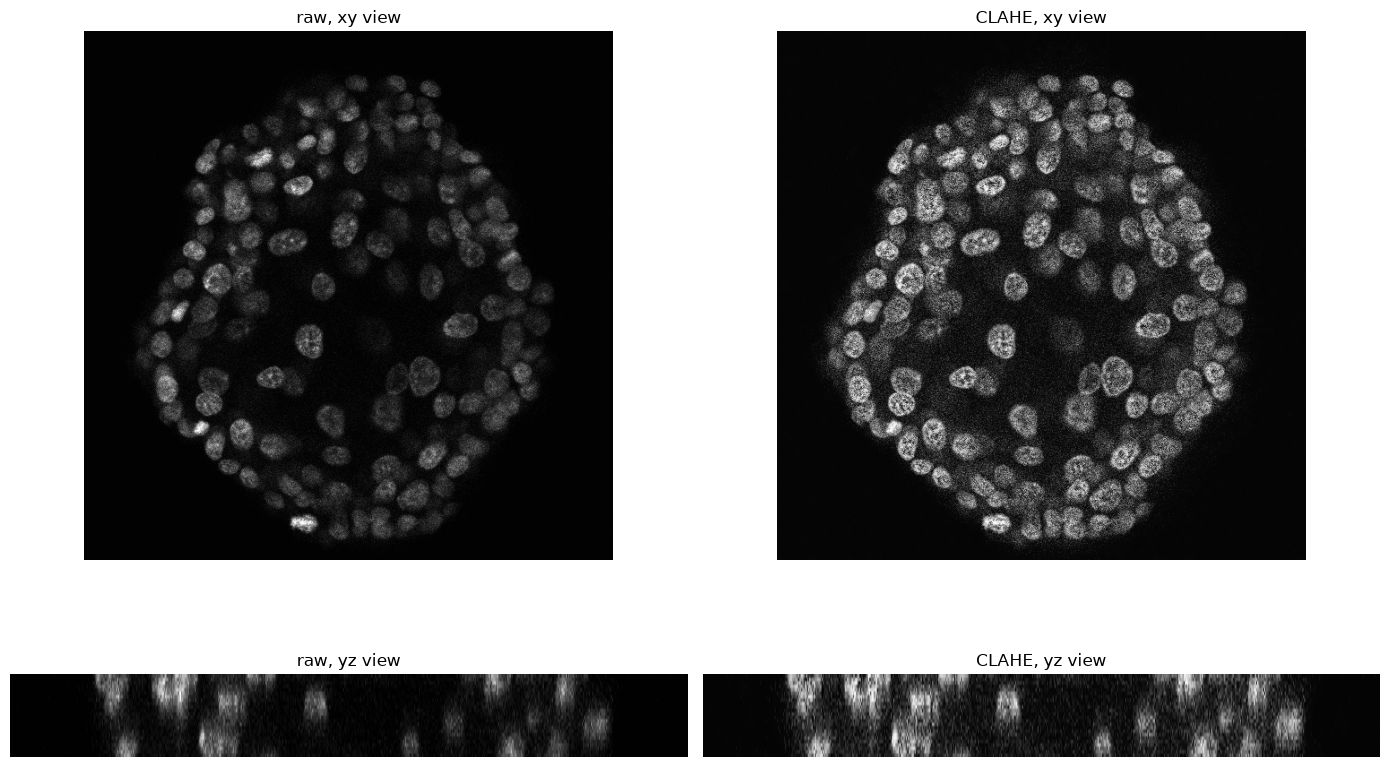

In [27]:
fig, axs = plt.subplots(2,2,figsize=(14,10))
axs[0][0].imshow(raw[halfz], cmap="gray")
axs[0][1].imshow(results_gpu[halfz], cmap="gray")
axs[1][0].imshow(raw[:,halfx,:], aspect = 3, cmap="gray")
axs[1][1].imshow(results_gpu[:,halfx,:], aspect = 3, cmap="gray")
axs[0][0].set_title('raw, xy view')
axs[0][1].set_title('CLAHE, xy view')
axs[1][0].set_title('raw, yz view')
axs[1][1].set_title('CLAHE, yz view')
for ax in axs.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

> Beware, as it increase contrast accross the image, CLAHE can increase noise in the image.